# **Darcy's Law in 1-Dimension**


In [1]:
using OralQual
using Distributions
using Random
using CairoMakie
using LinearAlgebra
using ColorSchemes
include("PrettyPlots.jl")

themed_figure

## **Setup**
Darcy's law describes the pressure field $p(\mathbf{x})$ of a porous medium, defined by a positive permeability field $a(\mathbf{x};\mathbf{v})$ that is parameterized by a parameter $\mathbf{v}$. In one dimension, Darcy's law is decribed by the boundary value problem:
$$
-\frac{d}{d\mathbf{x}}\left(a(\mathbf{x};\mathbf{v})\frac{d}{d\mathbf{x}}p(\mathbf{x})\right) = f(\mathbf{x}), \quad \mathbf{x}\in[0,1].
$$

We apply Dirichlet boundary conditions $p(0)=p(1)=0$, and $f$ is a function that defines the source of the fluid. Our goal is to infer the permeability field $a(\mathbf{x};\mathbf{v})$ given noisy measurements of the pressure $p(\mathbf{x})$.

### **Random log-Gaussian fields**
To formulate a *Bayesian* inverse problem, we assume prior $\log a(\mathbf{x};\mathbf{v})\sim\mathcal{N}(\boldsymbol{0},\mathbf{C})$, where:
$$
\mathbf{C} \equiv \left(-\Delta + \tau^2\mathbf{I}\right)^{-\alpha},
$$
where $-\Delta$ is the Laplacian on $[0, 1]$ with homogeneous Neumann boundary conditions on the space of spatial mean-zero functions, and $\tau,\alpha$ are known constants that control the lengthscales and smoothness of the Gaussian field. Under this paramterization, the random log-Gaussian field $\log a(\mathbf{x};\mathbf{v})$ admits Karhunen-Loeve (KL) expansion:

$$
\log a(\mathbf{x};\mathbf{v}) = \sum_{\ell=1}^\infty \mathbf{v}_\ell \sqrt{\xi_\ell}\boldsymbol{\psi}_\ell(\mathbf{x}),
$$

where $\mathbf{v}_\ell\sim\mathcal{N}(0, 1)$ and we have eigenpairs of $\mathbf{C}$:

$$
\xi_\ell = \left(\pi^2\ell^2  +   \tau^2\right)^{-\alpha}\text{  and  }\boldsymbol{\psi}(\mathbf{x}) = \sqrt{2}\cos(\pi\ell\mathbf{x}).
$$

### **Experimental setup**

* Sample ground truth $\mathbf{v}_\text{truth}\sim\mathcal{N}(\boldsymbol{0},\mathbf{I})$
* Generate truth log-Gaussian field $\log a(\mathbf{x};\mathbf{v}_\text{truth})$ as described above
* Solve Darcy flow equation using $\log a(\mathbf{x};\mathbf{v}_\text{truth})$ to generate pressure field $p(\mathbf{x})$
* Observe $p(\mathbf{x})$ and corrupt observations with Gaussian noise
* Use EKRMLE to try and reconstruct the underlying Gaussian field from noisy measurements of the pressure

In [6]:
N, L = 256, 1.0
Nₖ = 16 # number of KL modes
d = Nₖ
Δ_obs = 8 # separation between measurements
σ = 0.1
α = 2.0
τ = 3.0
darcy = Darcy_params(N,L,Nₖ,Δ_obs,d,α,τ)
𝛉 = darcy.θ_true
logK = darcy.logk
y_locs = darcy.y_locs
n = darcy.n
X = darcy.X
κ = exp.(logK)
sol = Darcy_1D_solver(darcy,κ)

y_nonoise = sol[y_locs] # observe solution
y = copy(y_nonoise)
for i = 1 : n
    y[i] += rand(Normal(0,σ^2)) # make noisy measurements
end


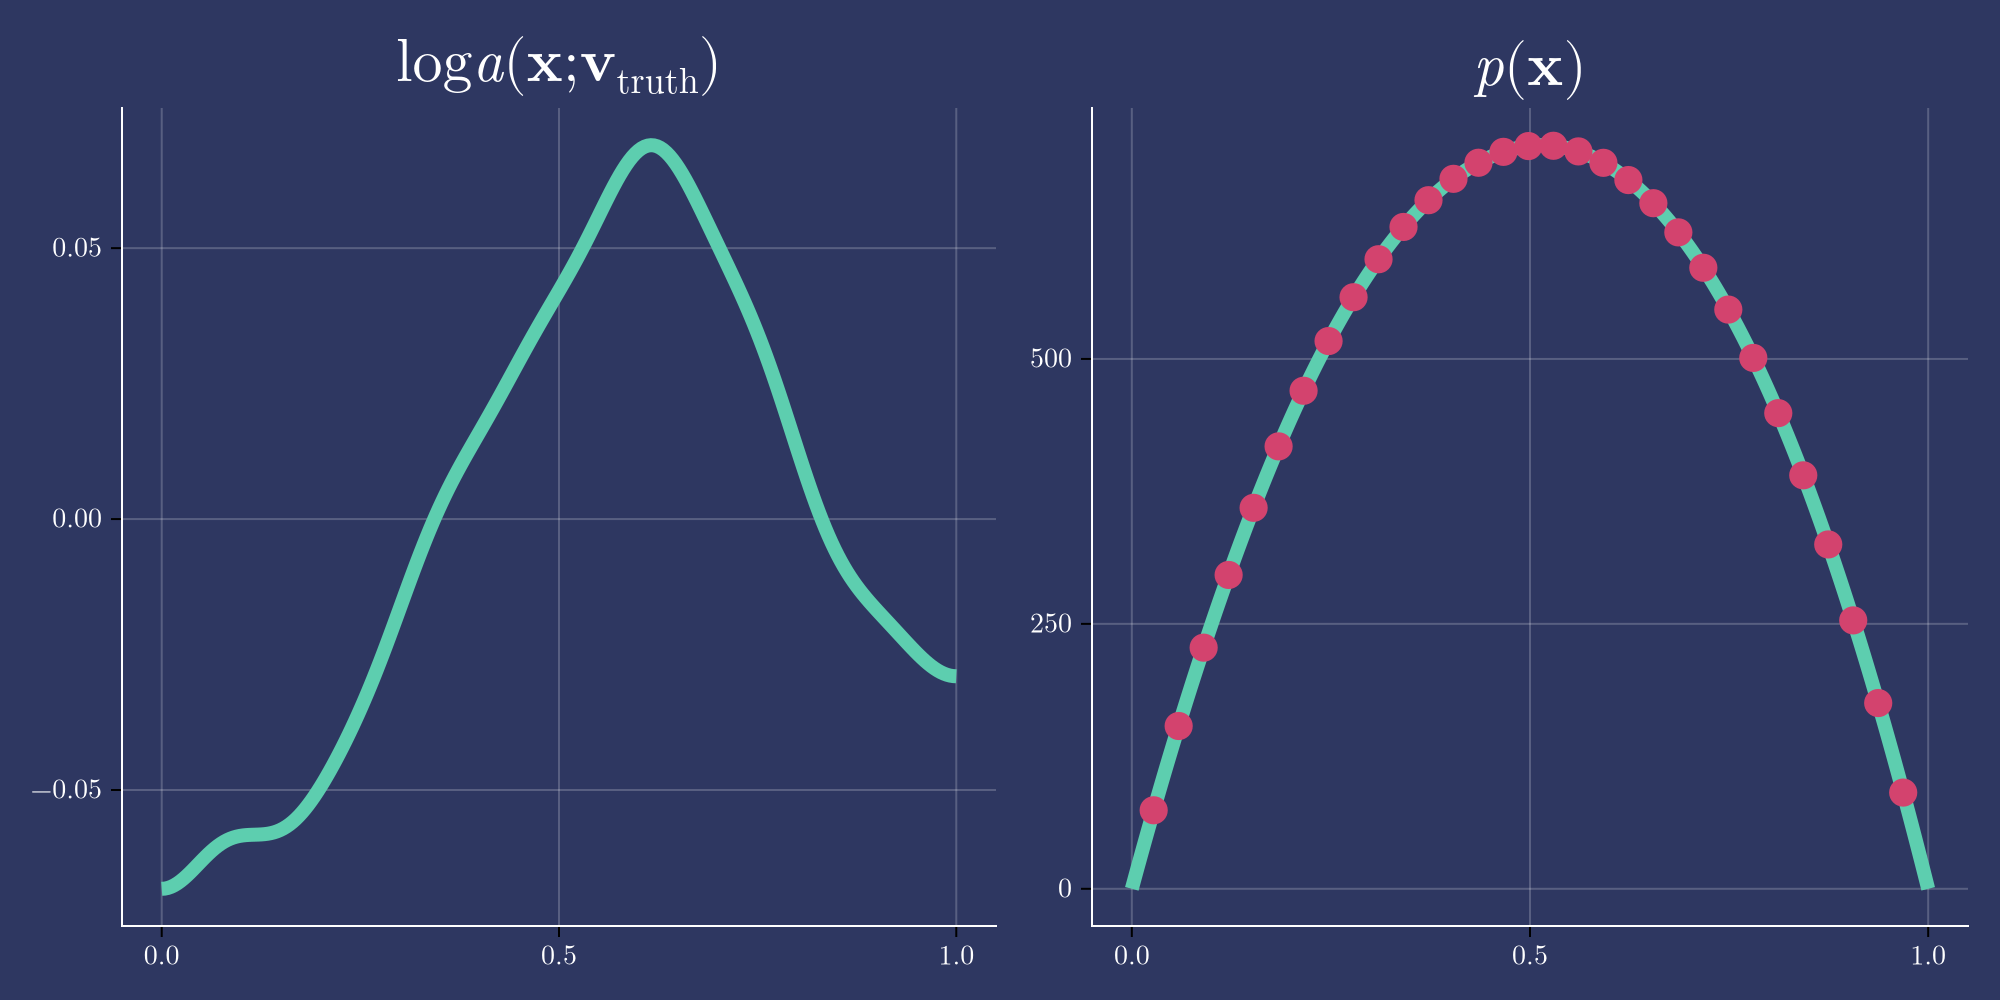

In [12]:
# Plot truth log field and data

colors = my_custom_dark_theme.palette.color[]
fig = themed_figure(; dark=true, size=(1000, 500)) do fig
    ax1 = Axis(fig[1, 1],
        title     = L"\log a(𝐱; 𝐯_\text{truth})",
        titlesize = 30,
    )
    ax2 = Axis(fig[1, 2],
        title     = L"p(𝐱)",
        titlesize = 30,
    )

    lines!(ax1, X, logK;
        linewidth = 7,
        color = colors[4]
    )

    lines!(ax2, X, sol;
        linewidth = 7,
        color = colors[4]
    )

    scatter!(ax2, X[y_locs], y;
        markersize = 20,
        color = colors[2]
    )

    fig
end